In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib

# sweeps
import yaml

import pickle


from pathlib import Path
import distro

%load_ext watermark

In [ ]:
%load_ext IPython.extensions.autoreload
%autoreload 2

from text_visualizations.plotting import plot_tsne_colors
from text_visualizations.sweep_analysis_helpers import *

In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures/tmp")
data_path = Path("../data")

In [ ]:
plt.style.use("matplotlib_style.txt")

In [ ]:
%watermark -t -d -tz -u -v -iv -w -m -h -p transformers -p openTSNE
print(distro.name(pretty=True))

Last updated: 2025-06-03 15:59:26CEST

Python implementation: CPython
Python version       : 3.12.9
IPython version      : 9.0.2

openTSNE: 1.0.2

Compiler    : Clang 19.1.6 
OS          : Linux
Release     : 4.18.0-553.el8_10.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

Hostname: gber7

text_visualizations: 0.1.0
seaborn            : 0.13.2
black              : 25.1.0
numpy              : 2.1.3
pandas             : 2.2.3
distro             : 1.9.0
jupyter_black      : 0.4.0
pathlib            : 1.0.1
yaml               : 6.0.2
matplotlib         : 3.10.1

Watermark: 2.5.0

Rocky Linux 8.10 (Green Obsidian)


# Imports (general)

In [ ]:
%%time
iclr = pd.read_parquet(
    data_path / "iclr25v2.parquet",
    engine="fastparquet",  # "pyarrow",
)

CPU times: user 186 ms, sys: 68.8 ms, total: 255 ms
Wall time: 1.42 s


In [ ]:
pickle_in = open(
    data_path / "dict_label_to_color.pkl",
    "rb",
)
dict_label_to_color = pickle.load(pickle_in)

In [ ]:
colors_iclr = np.vectorize(dict_label_to_color.get)(iclr.labels)

# Analysis

## Exp024 -- lr sweep, AbstractAndCropDataset

In [ ]:
# load sweep summary
exp_name = "exp024"
date_today = "20250522"
saving_path = Path(f"sbert/iclr/{exp_name}_{date_today}")

with open(
    variables_path / saving_path / f"sweep_summary_{date_today}.yaml", "r"
) as f:
    sweep_summary = yaml.safe_load(f)

In [ ]:
sweep_summary

{'experiment_results': [{'params': {'training.lr': 0.05}, 'success': True},
  {'params': {'training.lr': 0.02}, 'success': True},
  {'params': {'training.lr': 0.01}, 'success': True},
  {'params': {'training.lr': 0.005}, 'success': True},
  {'params': {'training.lr': 0.002}, 'success': True},
  {'params': {'training.lr': 0.001}, 'success': True},
  {'params': {'training.lr': 0.0001}, 'success': True}],
 'hyper_sweep_file': 'train_model.py',
 'successful_experiments': 7,
 'sweep_config': '../configs/exp024.yaml',
 'total_experiments': 7}

In [ ]:
results = load_results_in_subdirs(sweep_summary, variables_path, saving_path)

In [ ]:
df_sweep_results = construct_results_df(results)

In [ ]:
df_sweep_results

,training.lr,loss,knn
0,0.0500,5.746143,0.179894
1,0.0200,5.739487,0.174074
2,0.0100,5.513254,0.171958
3,0.0050,4.108710,0.374074
4,0.0020,4.161520,0.337037
5,0.0010,4.223150,0.325397
6,0.0001,4.685547,0.260847


In [ ]:
print(df_sweep_results)

   training.lr      loss       knn
0       0.0500  5.746143  0.179894
1       0.0200  5.739487  0.174074
2       0.0100  5.513254  0.171958
3       0.0050  4.108710  0.374074
4       0.0020  4.161520  0.337037
5       0.0010  4.223150  0.325397
6       0.0001  4.685547  0.260847


## Exp025 -- AbstractAndCropDataset 250 epochs

### Import results

In [ ]:
exp_name = "exp025"
saving_path = Path(f"sbert/iclr/{exp_name}_20250526")

df_log_training = pd.read_hdf(
    variables_path / saving_path / "df_log_training.h5"
)

embeddings_2d = np.load(variables_path / saving_path / "embeddings_2d.npy")

# intermediate embeddings
# npz = np.load(variables_path / saving_path / "interm_embeddings_2d.npz")
# npz["embeddings_2d_epoch_0"].shape

In [ ]:
embeddings_2d.shape

(34524, 2)

In [ ]:
df_log_training

,epoch,loss,knn
0,0,4.930657,0.282011
1,50,3.533232,0.468254
2,100,3.290255,0.475661
3,150,3.067769,0.486772
4,200,2.858694,0.504233
5,249,2.733022,0.501058


### Plots

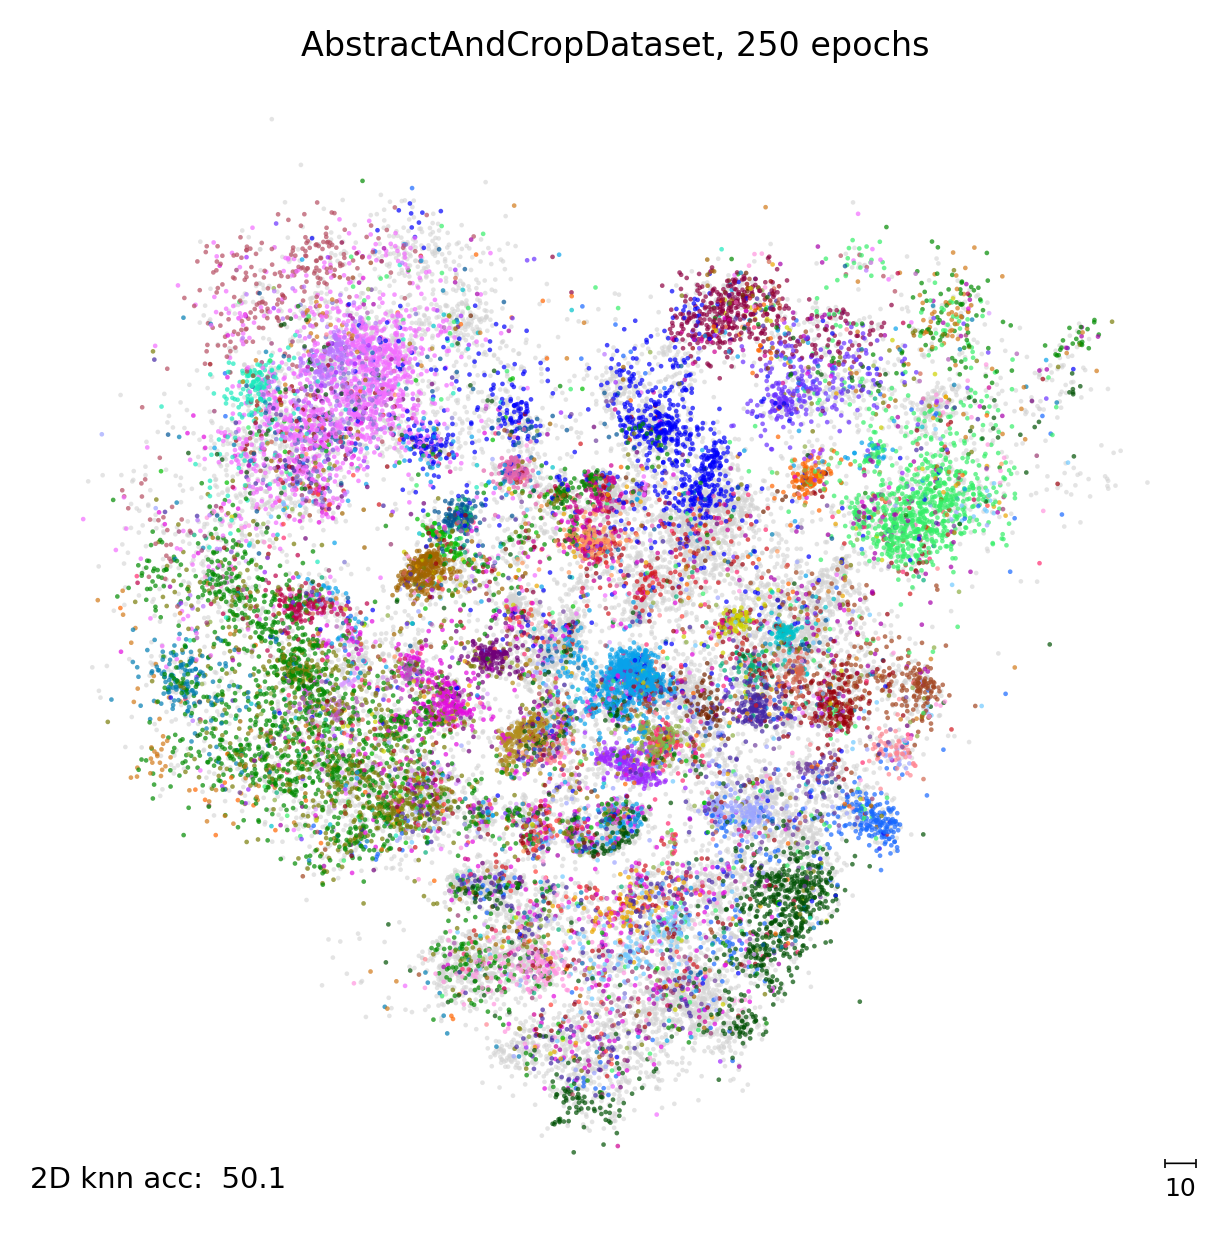

In [ ]:
fig, ax = plot_tsne_colors(embeddings_2d, colors_iclr, figsize=(4, 4))
ax.set_title("AbstractAndCropDataset, 250 epochs")
ax.text(
    0,
    0.01,
    f"2D knn acc:  {df_log_training.knn.iloc[-1]*100:.1f}",
    transform=ax.transAxes,
    va="bottom",
    ha="left",
    size=7,
)
add_scalebar_frac(ax)
fig.savefig(figures_path / f"embedding_{exp_name}_v1.png")

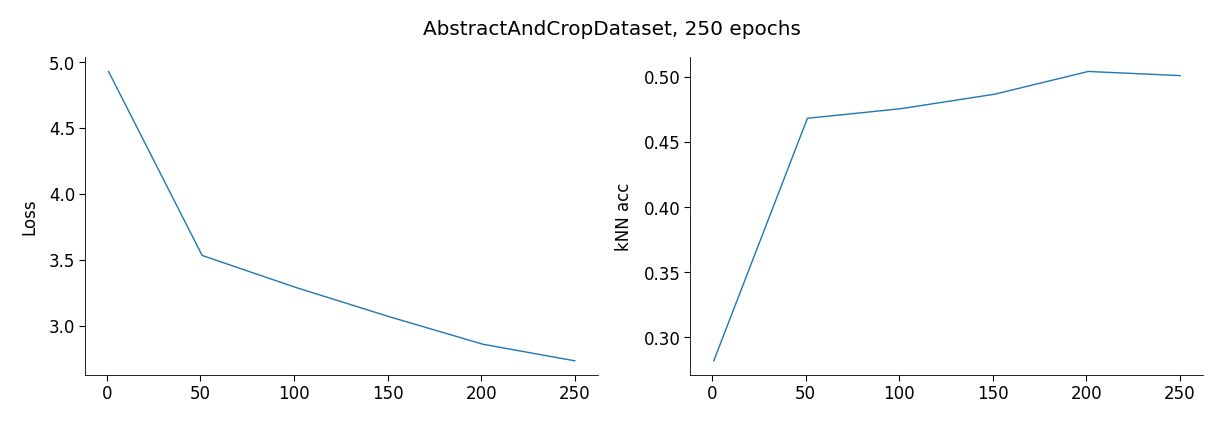

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2), dpi=200, layout="constrained")

ax[0].plot(df_log_training.epoch + 1, df_log_training.loss)
ax[0].set_ylabel("Loss")
ax[1].plot(df_log_training.epoch + 1, df_log_training.knn)
ax[1].set_ylabel("kNN acc")
fig.suptitle("AbstractAndCropDataset, 250 epochs")


fig.savefig(figures_path / f"loss_and_knn_acc_vs_epochs_{exp_name}_v1.png")

## Exp026 -- lr sweep, MaskedSentenceAbstractDataset

In [ ]:
# load sweep summary
exp_name = "exp026"
date_today = "20250523"
saving_path = Path(f"sbert/iclr/{exp_name}_{date_today}")

with open(
    variables_path / saving_path / f"sweep_summary_{date_today}.yaml", "r"
) as f:
    sweep_summary = yaml.safe_load(f)

In [ ]:
sweep_summary

{'experiment_results': [{'params': {'training.lr': 0.05}, 'success': True},
  {'params': {'training.lr': 0.02}, 'success': True},
  {'params': {'training.lr': 0.01}, 'success': True},
  {'params': {'training.lr': 0.005}, 'success': True},
  {'params': {'training.lr': 0.002}, 'success': True},
  {'params': {'training.lr': 0.001}, 'success': True},
  {'params': {'training.lr': 0.0001}, 'success': True}],
 'hyper_sweep_file': 'train_model.py',
 'successful_experiments': 7,
 'sweep_config': '../configs/exp026.yaml',
 'total_experiments': 7}

In [ ]:
results = load_results_in_subdirs(sweep_summary, variables_path, saving_path)

In [ ]:
df_sweep_results = construct_results_df(results)

In [ ]:
df_sweep_results

,training.lr,loss,knn
0,0.0500,4.215288,0.164021
1,0.0200,4.131995,0.210053
2,0.0100,4.210557,0.205820
3,0.0050,4.005050,0.243386
4,0.0020,3.018445,0.341270
5,0.0010,3.093424,0.330688
6,0.0001,3.653574,0.240212


In [ ]:
print(df_sweep_results)

   training.lr      loss       knn
0       0.0500  4.215288  0.164021
1       0.0200  4.131995  0.210053
2       0.0100  4.210557  0.205820
3       0.0050  4.005050  0.243386
4       0.0020  3.018445  0.341270
5       0.0010  3.093424  0.330688
6       0.0001  3.653574  0.240212


## Exp027 -- MaskedSentenceAbstractDataset 250 epochs

### Import results

In [ ]:
exp_name = "exp027"
saving_path = Path(f"sbert/iclr/{exp_name}_20250527")

df_log_training = pd.read_hdf(
    variables_path / saving_path / "df_log_training.h5"
)

embeddings_2d = np.load(variables_path / saving_path / "embeddings_2d.npy")

# intermediate embeddings
# npz = np.load(saving_path / "interm_embeddings_2d")
# npz["embeddings_2d_epoch_0"].shape

In [ ]:
embeddings_2d.shape

(34524, 2)

In [ ]:
df_log_training

,epoch,loss,knn
0,0,4.122415,0.252910
1,50,2.300731,0.455026
2,100,2.033548,0.474074
3,150,1.822173,0.491534
4,200,1.637053,0.491534
5,249,1.546169,0.502646


### Plots

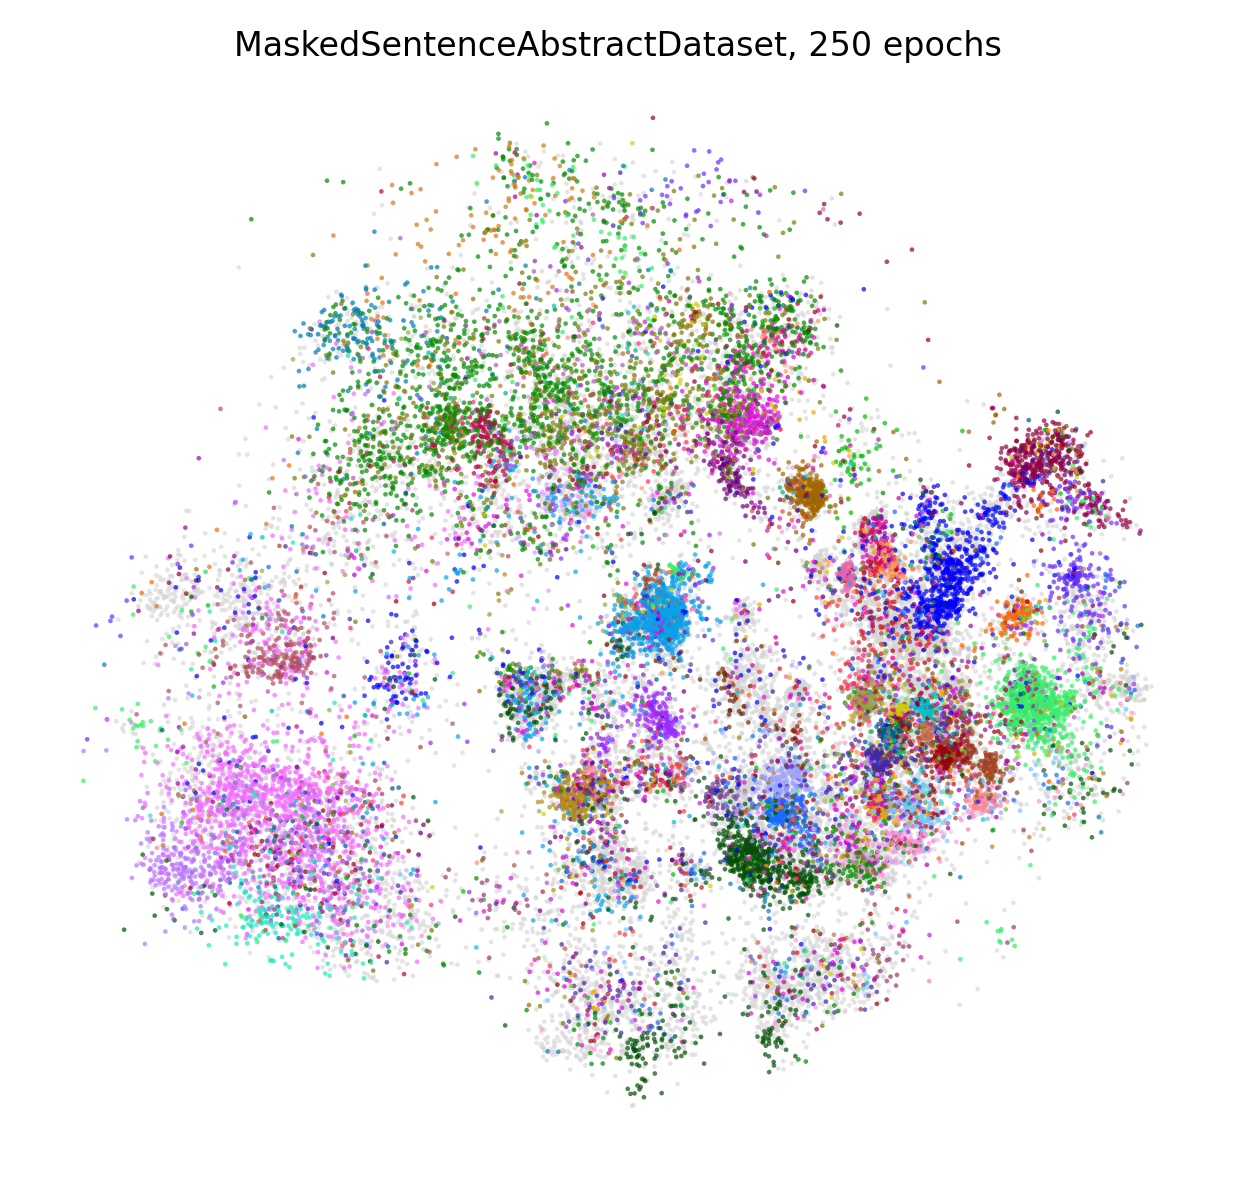

In [ ]:
fig, ax = plot_tsne_colors(embeddings_2d, colors_iclr, figsize=(4, 4))
ax.set_title("MaskedSentenceAbstractDataset, 250 epochs")
fig.savefig(figures_path / f"embedding_{exp_name}_v1.png")

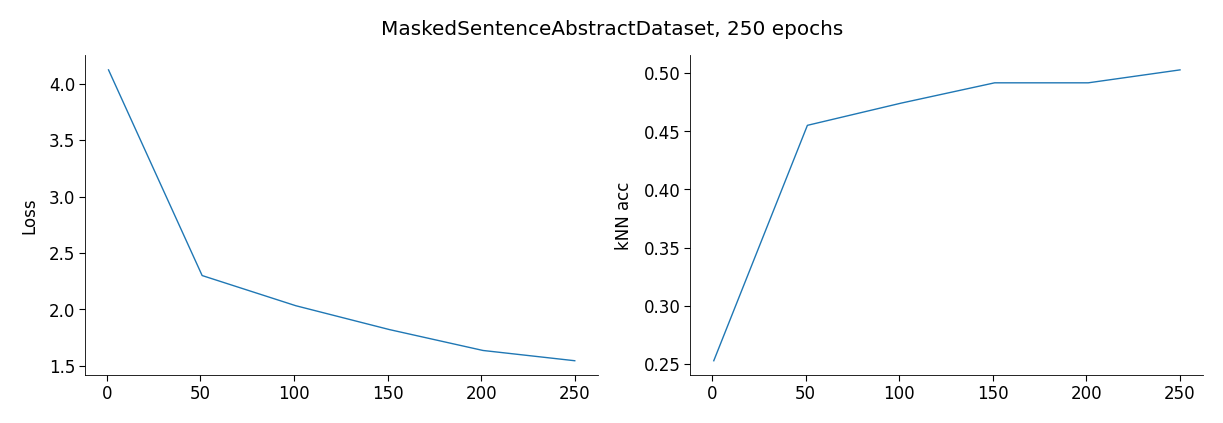

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2), dpi=200, layout="constrained")

ax[0].plot(df_log_training.epoch + 1, df_log_training.loss)
ax[0].set_ylabel("Loss")
ax[1].plot(df_log_training.epoch + 1, df_log_training.knn)
ax[1].set_ylabel("kNN acc")
fig.suptitle("MaskedSentenceAbstractDataset, 250 epochs")


fig.savefig(figures_path / f"loss_and_knn_acc_vs_epochs_{exp_name}_v1.png")